In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install openpyxl

## Data Loading

The dataset was loaded into a Pandas DataFrame and a copy was created to preserve the original data throughout the analysis process.

In [31]:
df_raw=pd.read_excel("Sejal_Babel_Portfolio_build.xlsx")

In [32]:
df=df_raw.copy()

In [33]:
print(df.columns)
print(df.shape)

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills'],
      dtype='str')
(32672, 16)


In [34]:
print(df.describe())
print(df.dtypes)

                  job_posted_date  salary_year_avg  salary_hour_avg
count                       32672     22036.000000     10636.000000
mean   2023-06-23 20:22:11.120439    123192.041852        47.028800
min           2023-01-01 00:01:11     15000.000000         8.000000
25%    2023-03-28 16:00:13.250000     90000.000000        27.500000
50%    2023-06-26 08:58:50.500000    115000.000000        46.000000
75%    2023-09-12 20:00:09.750000    150000.000000        61.159996
max           2023-12-31 23:40:32    960000.000000       391.000000
std                           NaN     48239.188733        21.847505
job_title_short                     str
job_title                           str
job_location                        str
job_via                             str
job_schedule_type                   str
job_work_from_home                 bool
search_location                     str
job_posted_date          datetime64[us]
job_no_degree_mention              bool
job_health_insurance        

## Data Quality Assessment

Before analysing the dataset, missing values and variable types were investigated.

In [36]:
df.isnull().sum()

job_title_short              0
job_title                    0
job_location               355
job_via                     10
job_schedule_type          141
job_work_from_home           0
search_location              0
job_posted_date              0
job_no_degree_mention        0
job_health_insurance         0
job_country                  0
salary_rate                  0
salary_year_avg          10636
salary_hour_avg          22036
company_name                 0
job_skills                3187
dtype: int64

## Handling Missing Salary Data

As the primary focus of this analysis is annual salary, missing values in the `salary_year_avg` column were addressed before proceeding.

Where `salary_year_avg` was missing but `salary_hour_avg` was available, the annual salary was estimated by converting the hourly rate to an annual equivalent. This conversion assumes a full-time schedule of 40 working hours per week and 52 working weeks per year (2,080 hours annually).

Records with missing values in both `salary_year_avg` and `salary_hour_avg` were removed from the dataset, as insufficient information was available to estimate annual compensation. 

In [75]:
rows_to_delete=[]
for n in range(len(df)):
    if pd.notna(df['salary_hour_avg'][n]) and pd.isna(df['salary_year_avg'][n]):
         df.loc[n,'salary_year_avg']=df['salary_hour_avg'][n]*40*52
    elif pd.isna(df['salary_hour_avg'][n]) and pd.isna(df['salary_year_avg'][n]):
        rows_to_delete.append(n)
df=df.drop(index=rows_to_delete)


In [76]:
df[['salary_year_avg', 'salary_hour_avg']].isna().sum()

salary_year_avg        0
salary_hour_avg    22036
dtype: int64

## Question 1

Which countries have the highest average salaries?

In [84]:
df['job_country']=df.job_country.str.strip()

In [118]:
average_by_country=df.groupby("job_country")['salary_year_avg'].mean().round(2).sort_values(ascending=False)
print(average_by_country)
size=len(average_by_country)
p1=average_by_country.iloc[0:25]
p2=average_by_country.iloc[25:50]
p3=average_by_country.iloc[50:75]
p4=average_by_country.iloc[75:100]
p5=average_by_country.iloc[100:size]

job_country
Russia        292500.00
Belarus       213520.00
Bahamas       193770.18
Venezuela     166400.00
Bolivia       166400.00
                ...    
Montenegro     49007.00
Algeria        43075.00
Gambia         31200.00
Benin          31200.00
Azerbaijan     30750.00
Name: salary_year_avg, Length: 111, dtype: float64


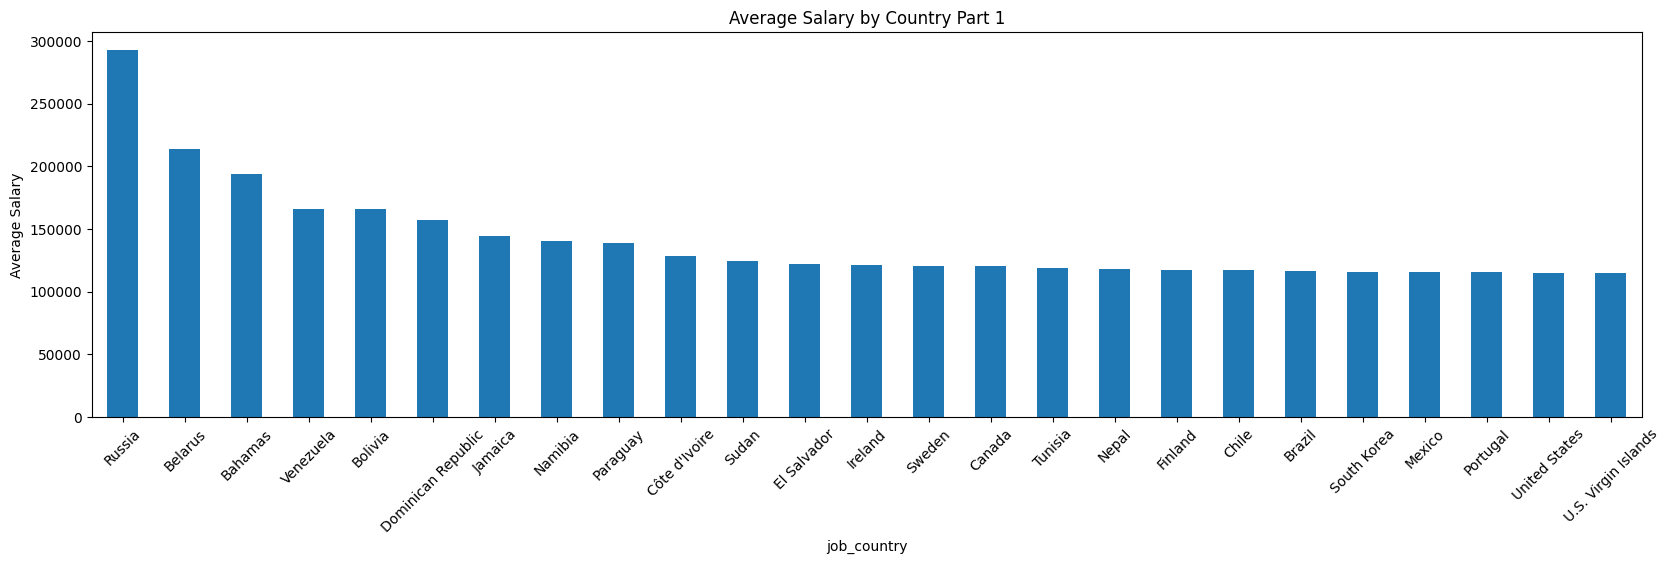

In [113]:
p1.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Country Part 1")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

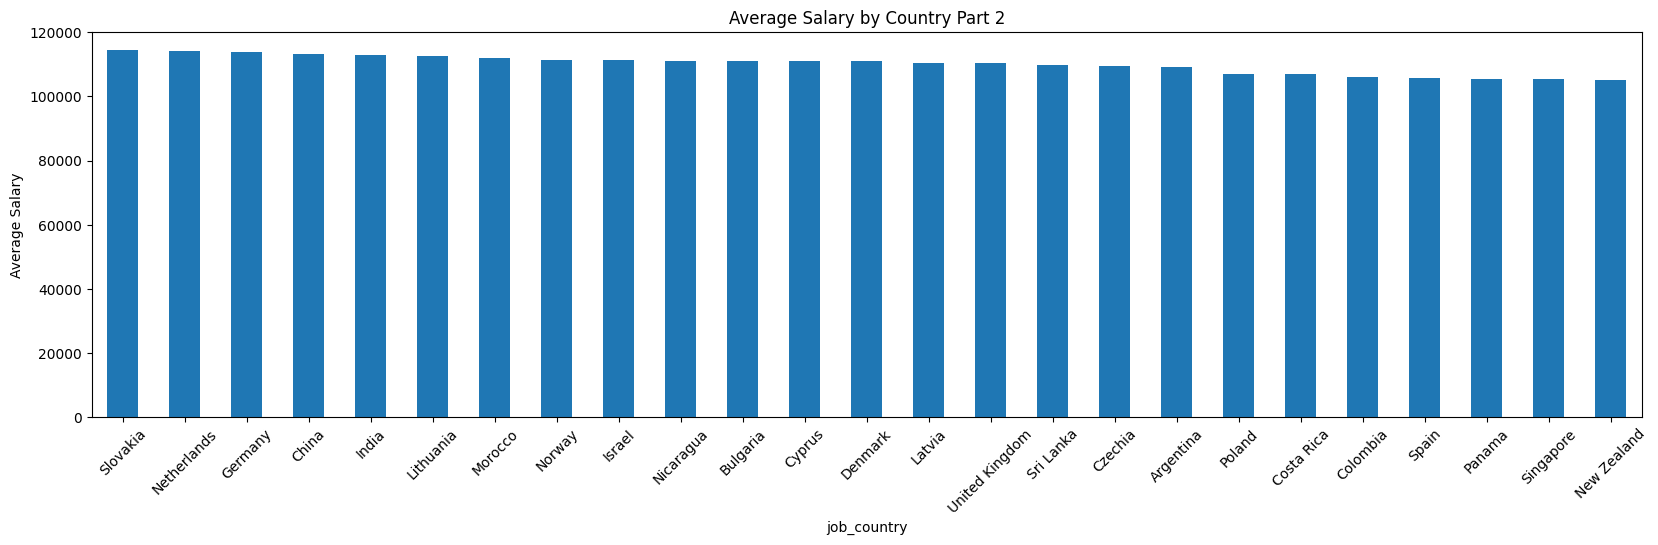

In [114]:
p2.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Country Part 2")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

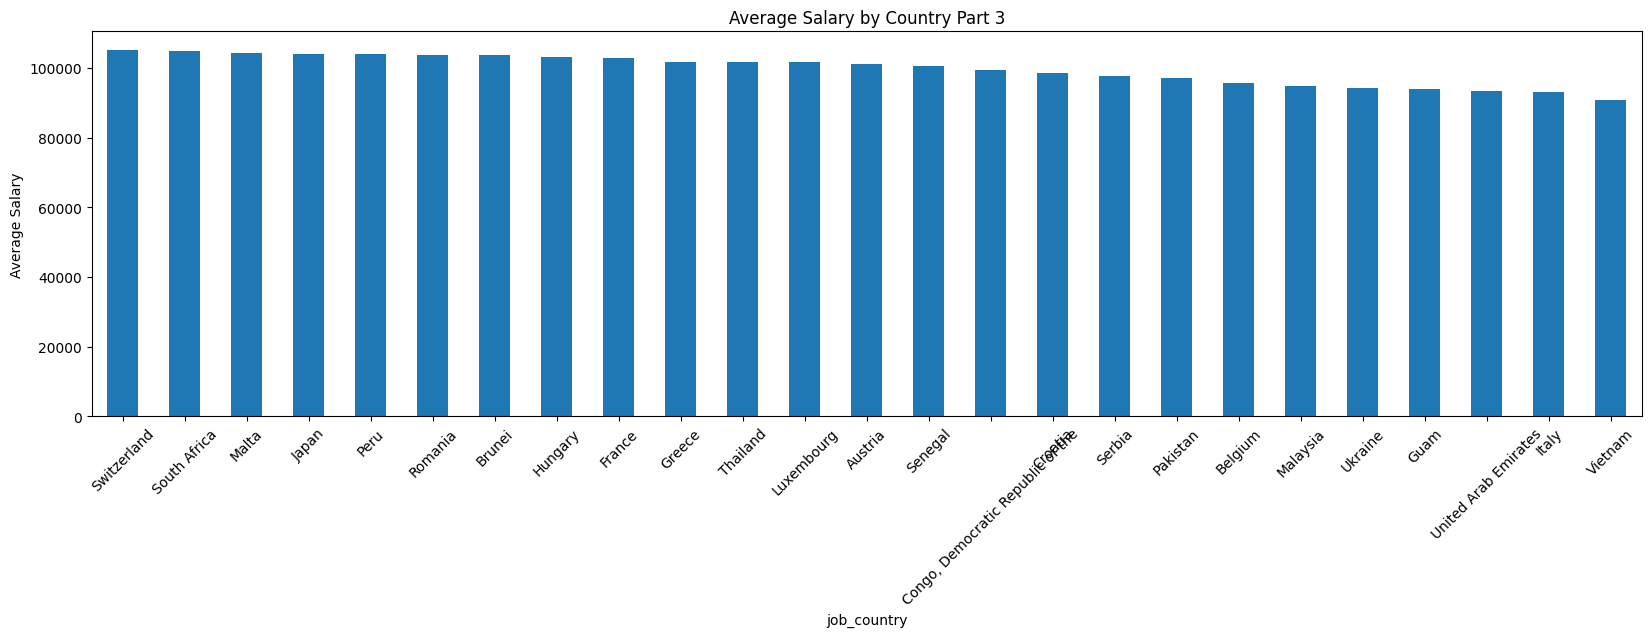

In [115]:
p3.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Country Part 3")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

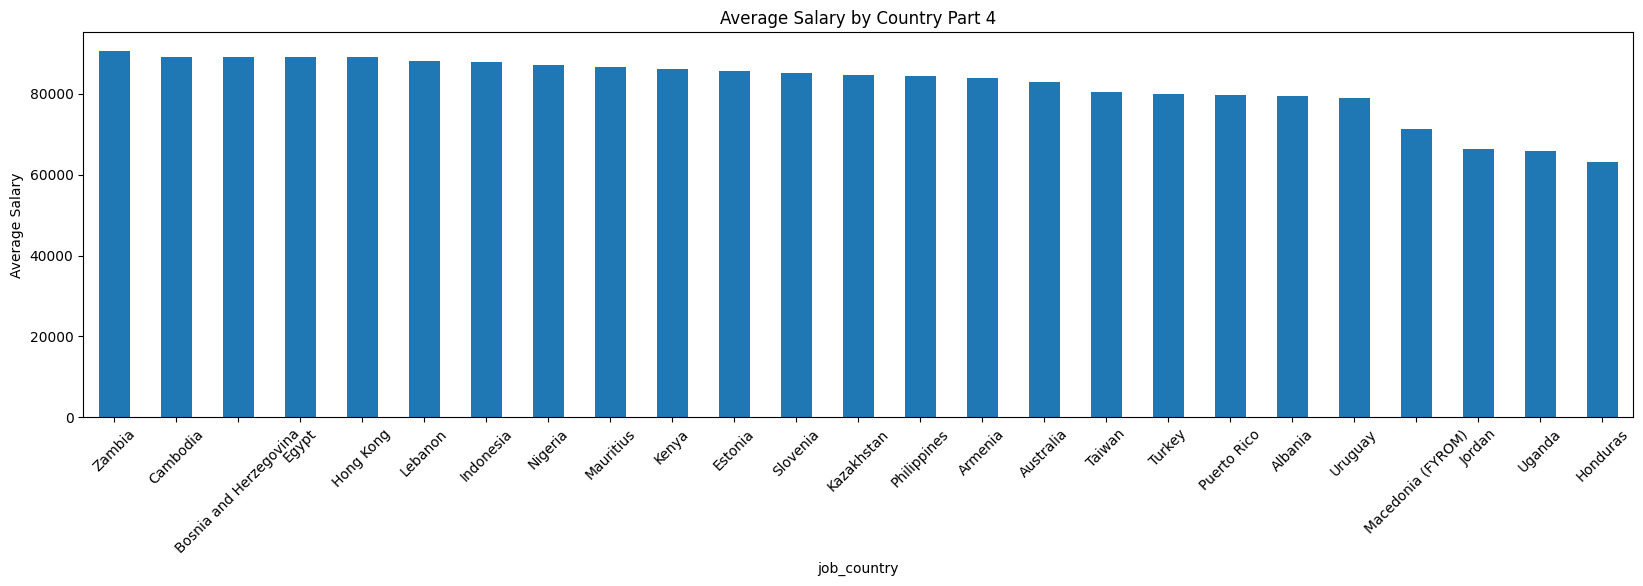

In [120]:
p4.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Country Part 4")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

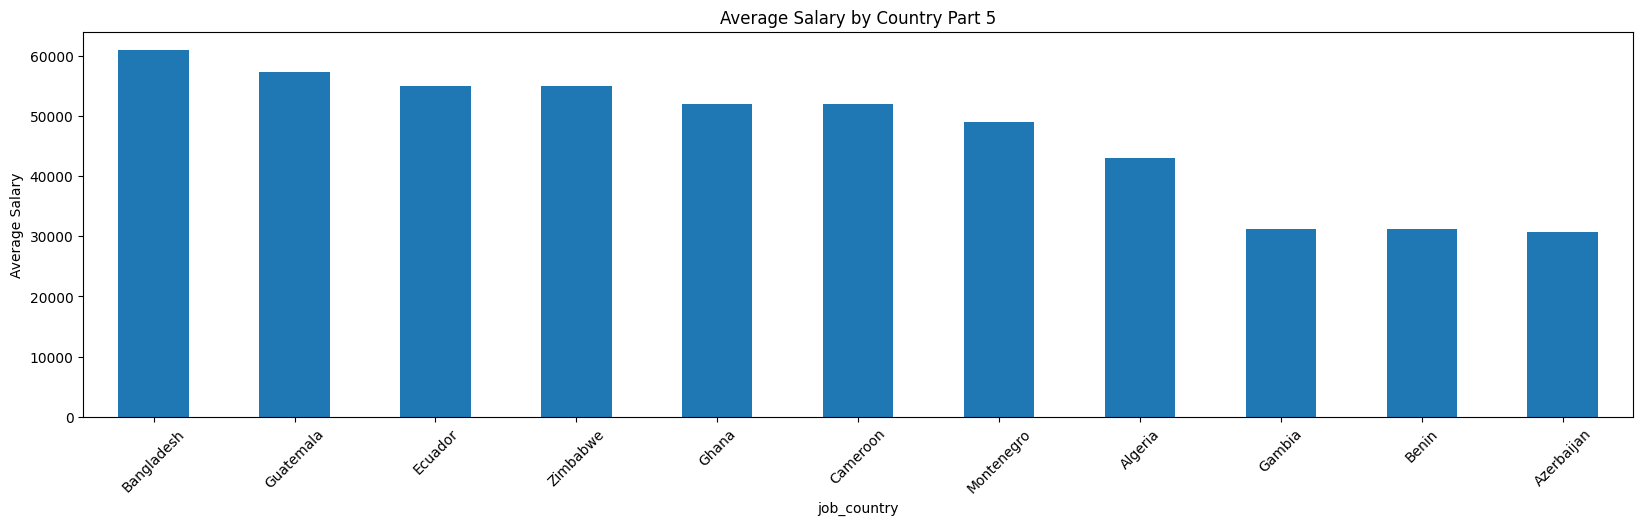

In [119]:
p5.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Country Part 5")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

## Problem 

The problem with the previous analysis is that average is irrelevant if the number of data points are too low. To avoid such situation, we only compute and plot the average salaries if the country has at least 100 entries. 

In [143]:
country_counts=df.job_country.value_counts()
valid_countries=country_counts[country_counts>=100].index
print(valid_countries)
average_salary_refined=df[df['job_country'].isin(valid_countries)].groupby("job_country")["salary_year_avg"].mean().round(2) 
print(average_salary_refined)

Index(['United States', 'Sudan', 'India', 'Canada', 'United Kingdom',
       'Germany', 'France', 'Poland', 'Australia', 'Spain', 'Portugal',
       'Mexico', 'Israel', 'Singapore'],
      dtype='str', name='job_country')
job_country
Australia          82806.53
Canada            120454.46
France            102973.75
Germany           113858.62
India             112870.00
Israel            111304.06
Mexico            115530.67
Poland            107003.70
Portugal          115468.68
Singapore         105351.39
Spain             105719.01
Sudan             124399.55
United Kingdom    110518.39
United States     115334.05
Name: salary_year_avg, dtype: float64


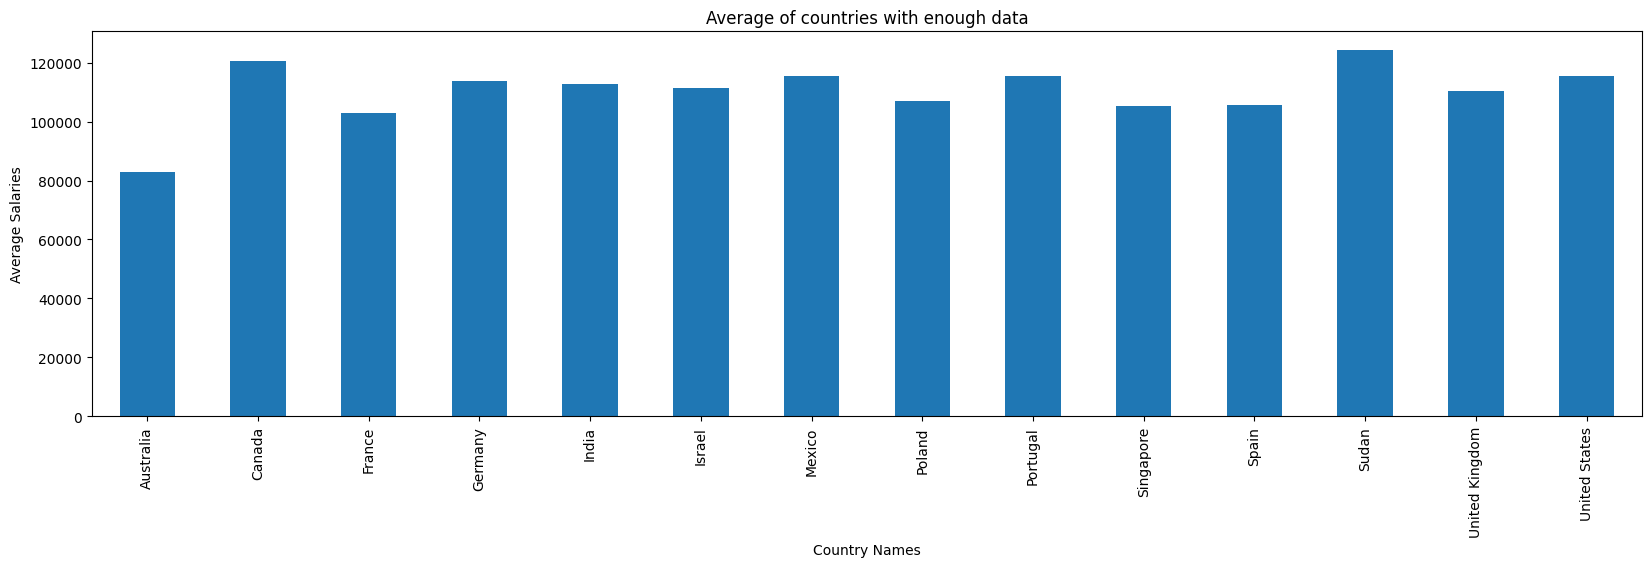

In [145]:
average_salary_refined.plot(kind="bar", figsize=(20,5))
plt.title("Average of countries with enough data")
plt.ylabel("Average Salaries")
plt.xlabel("Country Names")
plt.show()

## Question 2 

 Which job title has the highest average salaries?

In [165]:
df.job_title_short.unique()
job_title_count=df['job_title_short'].value_counts()
job_titles_enough_data=job_title_count[job_title_count>=100].index
average_salary_by_job_title= df[df['job_title_short'].isin(job_titles_enough_data)].groupby("job_title_short")["salary_year_avg"].mean().round(2).sort_values(ascending=False)
print(average_salary_by_job_title)    

job_title_short
Senior Data Scientist        147419.27
Senior Data Engineer         142786.61
Data Engineer                126369.57
Data Scientist               125861.71
Machine Learning Engineer    125008.66
Senior Data Analyst          109998.21
Software Engineer            109980.50
Business Analyst              90398.10
Data Analyst                  87588.71
Name: salary_year_avg, dtype: float64


Text(0.5, 0, 'Job Title')

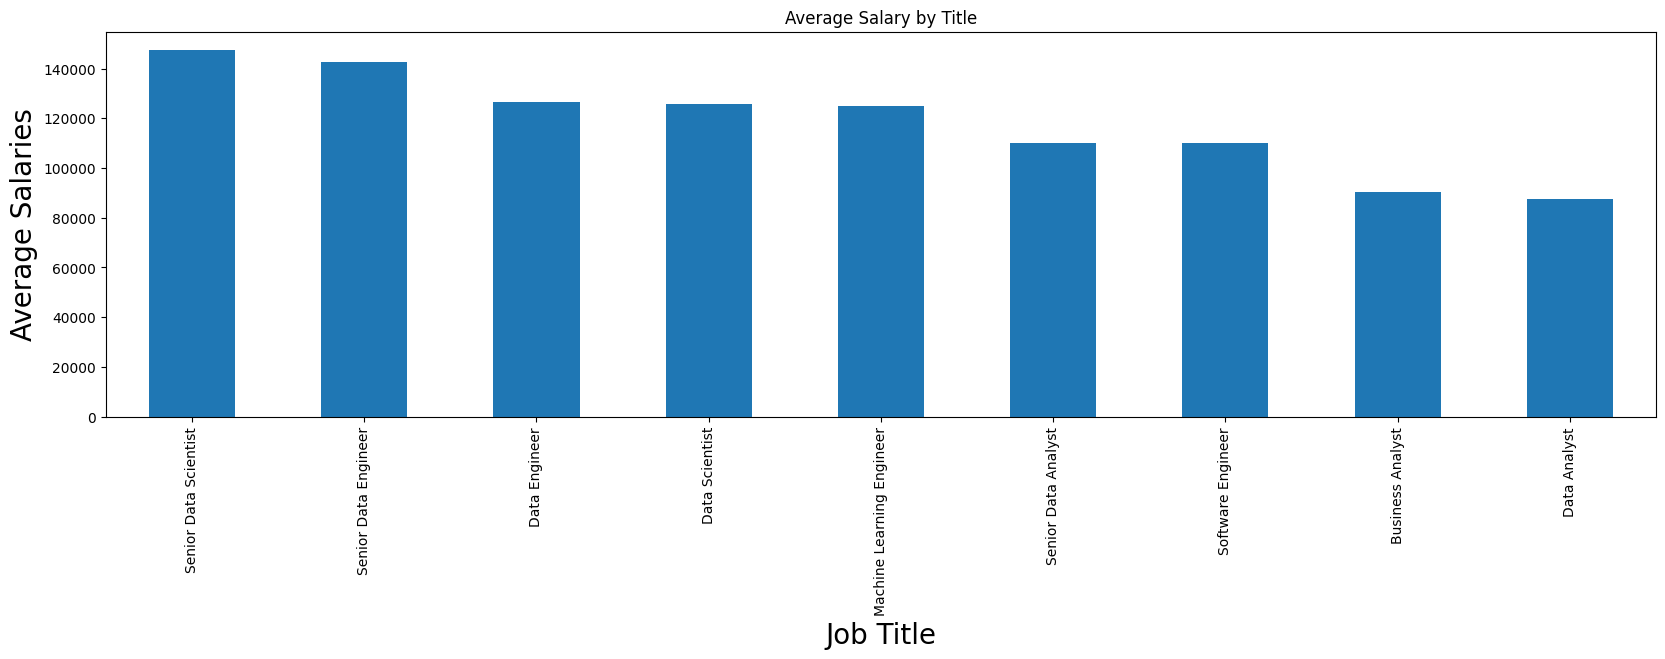

In [170]:
average_salary_by_job_title.plot(kind="bar", figsize=(20,5))
plt.title("Average Salary by Title")
plt.ylabel("Average Salaries", fontsize=20)
plt.xlabel("Job Title", fontsize=20)

## Question 3 

Which job title has the highest average salary in each country, considering only countries with at least 100 job postings?


In [173]:
Salary_structure=df[df['job_title_short'].isin(job_titles_enough_data) & df['job_country'].isin(valid_countries)].groupby(["job_title_short", "job_country"])["salary_year_avg"].mean().round(2)

In [180]:
Salary_structure=pd.DataFrame(Salary_structure)
print(Salary_structure)

                                  salary_year_avg
job_title_short   job_country                    
Business Analyst  Australia              61342.86
                  Canada                 84595.38
                  France                 81158.33
                  Germany                75296.15
                  India                  76204.10
...                                           ...
Software Engineer Singapore              74283.70
                  Spain                  97660.00
                  Sudan                 129922.60
                  United Kingdom        103280.00
                  United States         124463.92

[125 rows x 1 columns]


In [198]:
# Which country and job title has highest salary? 
Salary_structure.loc[
    Salary_structure["salary_year_avg"].idxmax()
]

salary_year_avg    152738.89
Name: (Senior Data Scientist, Mexico), dtype: float64

In [184]:
salary_pivot = Salary_structure.reset_index().pivot(
    index="job_title_short",
    columns="job_country",
    values="salary_year_avg"
)

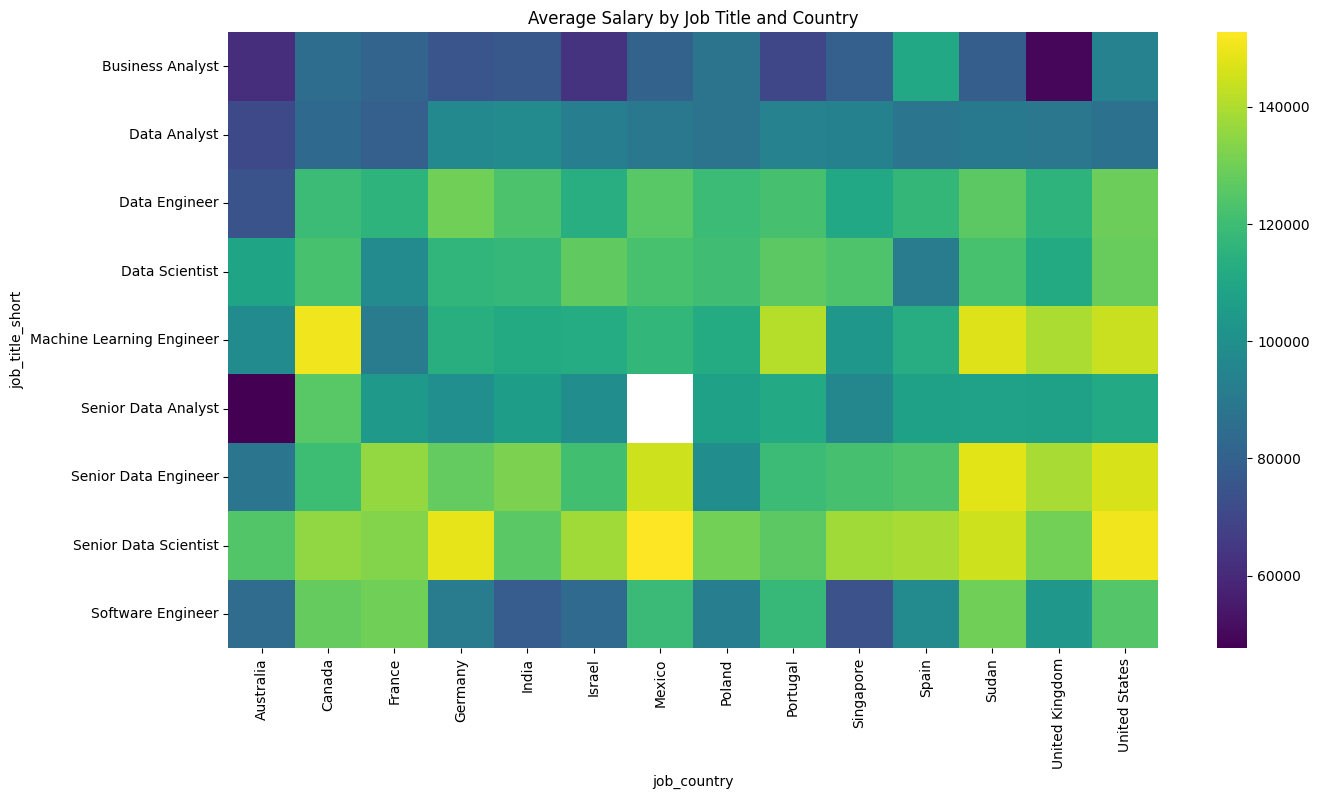

In [185]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.heatmap(salary_pivot, cmap="viridis")
plt.title("Average Salary by Job Title and Country")
plt.show()